In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# 读取 Cookie Cats A/B 测试数据
data_path = Path("archive (3)") / "cookie_cats.csv"
df = pd.read_csv(data_path)

# 基础数据检查
print("数据规模：", df.shape)
print("重复用户数：", df["userid"].duplicated().sum())
print("\n各实验组样本量：")
display(df["version"].value_counts())

display(df.head())
df.info()

数据规模： (90189, 5)
重复用户数： 0

各实验组样本量：


version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


<class 'pandas.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   userid          90189 non-null  int64
 1   version         90189 non-null  str  
 2   sum_gamerounds  90189 non-null  int64
 3   retention_1     90189 non-null  bool 
 4   retention_7     90189 non-null  bool 
dtypes: bool(2), int64(2), str(1)
memory usage: 2.2 MB


In [2]:
from scipy.stats import chisquare

# 设定分组顺序：gate_30 为对照组，gate_40 为实验组
group_counts = (
    df["version"]
    .value_counts()
    .reindex(["gate_30", "gate_40"])
)

expected_counts = [len(df) / 2, len(df) / 2]

chi2_stat, p_value_srm = chisquare(
    f_obs=group_counts,
    f_exp=expected_counts,
)

print("实际样本量：")
display(group_counts)

print(f"SRM 卡方统计量：{chi2_stat:.4f}")
print(f"SRM p 值：{p_value_srm:.4f}")

if p_value_srm < 0.05:
    print("结论：存在样本比例失衡，需要谨慎解释实验结果。")
else:
    print("结论：未发现明显样本比例失衡，可继续进行 A/B 测试。")

实际样本量：


version
gate_30    44700
gate_40    45489
Name: count, dtype: int64

SRM 卡方统计量：6.9024
SRM p 值：0.0086
结论：存在样本比例失衡，需要谨慎解释实验结果。


In [3]:
# 计算两组的核心指标
group_summary = (
    df
    .groupby("version", as_index=False)
    .agg(
        users=("userid", "nunique"),
        avg_game_rounds=("sum_gamerounds", "mean"),
        retention_1_rate=("retention_1", "mean"),
        retention_7_rate=("retention_7", "mean"),
    )
)

# 转为百分比，便于阅读
for col in ["retention_1_rate", "retention_7_rate"]:
    group_summary[col] = (
        group_summary[col] * 100
    ).round(2)

display(group_summary)

,version,users,avg_game_rounds,retention_1_rate,retention_7_rate
0,gate_30,44700,52.456264,44.82,19.02
1,gate_40,45489,51.298776,44.23,18.20


In [4]:
import numpy as np
from statsmodels.stats.proportion import (
    proportions_ztest,
    confint_proportions_2indep,
)

# 对照组与实验组的 7 日留存成功人数、样本量
control = df.loc[df["version"].eq("gate_30")]
treatment = df.loc[df["version"].eq("gate_40")]

control_success = control["retention_7"].sum()
treatment_success = treatment["retention_7"].sum()

control_n = len(control)
treatment_n = len(treatment)

# 两样本比例 Z 检验：H0 为两组 7 日留存率相同
z_stat, p_value = proportions_ztest(
    count=np.array([control_success, treatment_success]),
    nobs=np.array([control_n, treatment_n]),
    alternative="two-sided",
)

# 效应量：实验组留存率 - 对照组留存率
control_rate = control_success / control_n
treatment_rate = treatment_success / treatment_n
diff_pp = (treatment_rate - control_rate) * 100

# 95% 置信区间，单位转换为百分点
ci_low, ci_high = confint_proportions_2indep(
    count1=treatment_success,
    nobs1=treatment_n,
    count2=control_success,
    nobs2=control_n,
    compare="diff",
    method="wald",
)

print(f"对照组 7 日留存率：{control_rate:.2%}")
print(f"实验组 7 日留存率：{treatment_rate:.2%}")
print(f"留存率差异（实验组 - 对照组）：{diff_pp:.2f} 个百分点")
print(f"Z 统计量：{z_stat:.4f}")
print(f"p 值：{p_value:.4f}")
print(f"95% 置信区间：[{ci_low * 100:.2f}, {ci_high * 100:.2f}] 个百分点")

对照组 7 日留存率：19.02%
实验组 7 日留存率：18.20%
留存率差异（实验组 - 对照组）：-0.82 个百分点
Z 统计量：3.1644
p 值：0.0016
95% 置信区间：[-1.33, -0.31] 个百分点


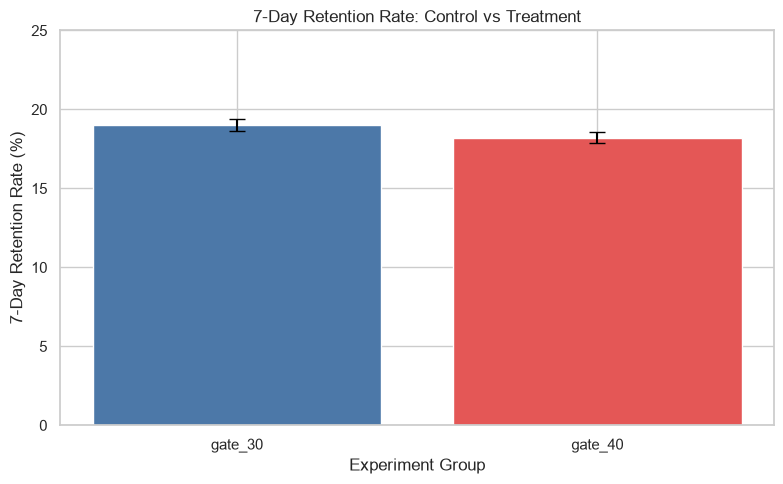

In [5]:
from statsmodels.stats.proportion import proportion_confint

plot_data = pd.DataFrame({
    "group": ["gate_30", "gate_40"],
    "retention_7_rate": [control_rate, treatment_rate],
    "success": [control_success, treatment_success],
    "nobs": [control_n, treatment_n],
})

# 计算每组留存率的 Wilson 95% 置信区间
ci = plot_data.apply(
    lambda row: proportion_confint(
        count=row["success"],
        nobs=row["nobs"],
        method="wilson",
    ),
    axis=1,
)

plot_data["ci_low"] = [item[0] for item in ci]
plot_data["ci_high"] = [item[1] for item in ci]

# 绘制留存率与 95% 置信区间
plt.figure(figsize=(8, 5))

plt.bar(
    plot_data["group"],
    plot_data["retention_7_rate"] * 100,
    color=["#4C78A8", "#E45756"],
)

plt.errorbar(
    x=plot_data["group"],
    y=plot_data["retention_7_rate"] * 100,
    yerr=[
        (plot_data["retention_7_rate"] - plot_data["ci_low"]) * 100,
        (plot_data["ci_high"] - plot_data["retention_7_rate"]) * 100,
    ],
    fmt="none",
    color="black",
    capsize=6,
)

plt.title("7-Day Retention Rate: Control vs Treatment")
plt.xlabel("Experiment Group")
plt.ylabel("7-Day Retention Rate (%)")
plt.ylim(0, 25)

plt.tight_layout()
plt.show()

In [6]:
# 复用两样本比例检验逻辑，比较次日留存率
control_retention_1 = control["retention_1"].sum()
treatment_retention_1 = treatment["retention_1"].sum()

z_stat_1d, p_value_1d = proportions_ztest(
    count=np.array([
        control_retention_1,
        treatment_retention_1,
    ]),
    nobs=np.array([
        control_n,
        treatment_n,
    ]),
    alternative="two-sided",
)

control_rate_1d = control_retention_1 / control_n
treatment_rate_1d = treatment_retention_1 / treatment_n
diff_pp_1d = (treatment_rate_1d - control_rate_1d) * 100

print(f"对照组次日留存率：{control_rate_1d:.2%}")
print(f"实验组次日留存率：{treatment_rate_1d:.2%}")
print(f"留存率差异（实验组 - 对照组）：{diff_pp_1d:.2f} 个百分点")
print(f"p 值：{p_value_1d:.4f}")

对照组次日留存率：44.82%
实验组次日留存率：44.23%
留存率差异（实验组 - 对照组）：-0.59 个百分点
p 值：0.0744


In [7]:
from scipy.stats import mannwhitneyu

# 两组用户的 14 天累计游戏轮次
control_rounds = control["sum_gamerounds"]
treatment_rounds = treatment["sum_gamerounds"]

# 非参数检验：比较两组游戏轮次分布是否存在差异
u_stat, p_value_rounds = mannwhitneyu(
    control_rounds,
    treatment_rounds,
    alternative="two-sided",
)

rounds_summary = pd.DataFrame({
    "group": ["gate_30", "gate_40"],
    "mean_rounds": [
        control_rounds.mean(),
        treatment_rounds.mean(),
    ],
    "median_rounds": [
        control_rounds.median(),
        treatment_rounds.median(),
    ],
})

display(rounds_summary.round(2))

print(f"Mann-Whitney U 统计量：{u_stat:.0f}")
print(f"p 值：{p_value_rounds:.4f}")

,group,mean_rounds,median_rounds
0,gate_30,52.46,17.0
1,gate_40,51.30,16.0


Mann-Whitney U 统计量：1024331250
p 值：0.0502


In [8]:
experiment_summary = pd.DataFrame({
    "metric": [
        "7日留存率",
        "次日留存率",
        "平均游戏轮次",
    ],
    "control_group": [
        f"{control_rate:.2%}",
        f"{control_rate_1d:.2%}",
        f"{control_rounds.mean():.2f}",
    ],
    "treatment_group": [
        f"{treatment_rate:.2%}",
        f"{treatment_rate_1d:.2%}",
        f"{treatment_rounds.mean():.2f}",
    ],
    "treatment_minus_control": [
        f"{diff_pp:.2f} 个百分点",
        f"{diff_pp_1d:.2f} 个百分点",
        f"{treatment_rounds.mean() - control_rounds.mean():.2f}",
    ],
    "p_value": [
        round(p_value, 4),
        round(p_value_1d, 4),
        round(p_value_rounds, 4),
    ],
})

display(experiment_summary)

,metric,control_group,treatment_group,treatment_minus_control,p_value
0,7日留存率,19.02%,18.20%,-0.82 个百分点,0.0016
1,次日留存率,44.82%,44.23%,-0.59 个百分点,0.0744
2,平均游戏轮次,52.46,51.30,-1.16,0.0502


# A/B 测试结论

## 实验问题
评估将 Cookie Cats 首次关卡门槛从 30 关（gate_30，对照组）后移至 40 关（gate_40，实验组），是否能够提升用户留存与参与度。

## 数据质量检查
- 共 90,189 名用户，未发现重复用户和缺失值。
- SRM 检查 p 值为 0.0086，存在样本比例失衡风险；正式业务决策前应排查分流逻辑、埋点与数据抽取范围。

## 核心结果
- 7 日留存率：实验组为 18.20%，对照组为 19.02%，下降 0.82 个百分点，p=0.0016，差异显著。
- 次日留存率：实验组为 44.23%，对照组为 44.82%，下降 0.59 个百分点，p=0.0744，差异不显著。
- 平均游戏轮次：实验组为 51.30，对照组为 52.46，p=0.0502，未达到 5% 显著性水平，但存在轻微下降趋势。

## 业务建议
不建议将首次关卡门槛从 30 关直接后移至 40 关。该改动显著降低 7 日留存率，且未带来短期留存或游戏参与度的显著提升。建议保留 gate_30 方案，并在修复 SRM 问题后重新设计和运行实验。